<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Naive_Bayes_Algorithm_on_Spam_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df = df[['v1','v2']]

In [6]:
df.columns = ['label','messages']

In [7]:
df.head()

,label,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [9]:
df.head()

,label,messages
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df['label'].value_counts()

,count
label,
0,4825
1,747


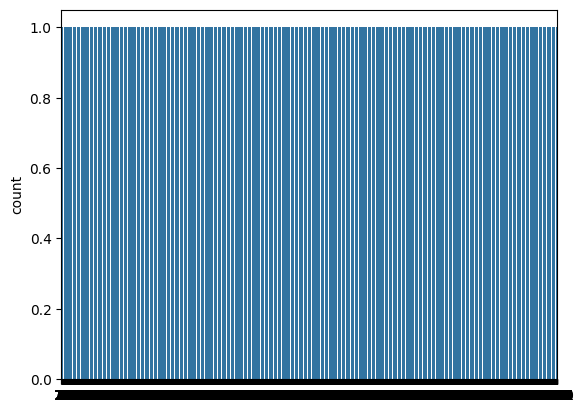

In [14]:
sns.countplot(df['label'])
plt.show()

In [15]:
df['length'] = df['messages'].apply(len)

In [16]:
df.head()

,label,messages,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


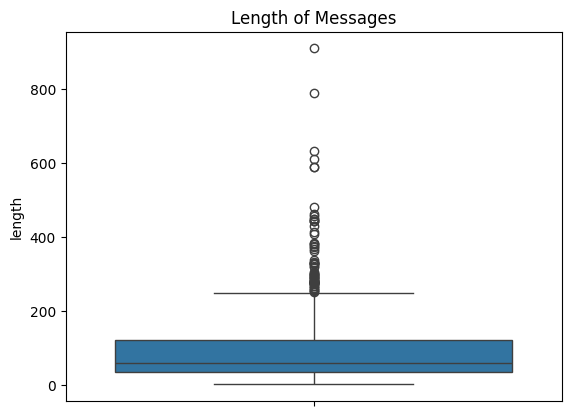

In [17]:
sns.boxplot(df['length'])
plt.title('Length of Messages')
plt.show()

In [18]:
Q1 = df['length'].quantile(0.25)
Q3 = df['length'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['length'] >= lower) & (df['length'] <= upper)]

In [21]:
import nltk
import string
from nltk.corpus import stopwords

In [22]:
def clean_text(text):
  text = text.lower()

  text = "".join([
      char for char in text
      if char not in string.punctuation
  ])

  words = text.split()
  words = [
      word for word in words
      if word not in stopwords.words('english')
  ]

  return " ".join(words)

In [26]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [27]:
df["clean_message"] = df["messages"].apply(clean_text)

/tmp/ipykernel_395/1405229012.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["clean_message"] = df["messages"].apply(clean_text)


In [28]:
df.head()

,label,messages,length,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goes usf lives around though


In [29]:
df['word_count'] = df['clean_message'].apply(
    lambda x:len(x.split())
)

/tmp/ipykernel_395/379140512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['clean_message'].apply(


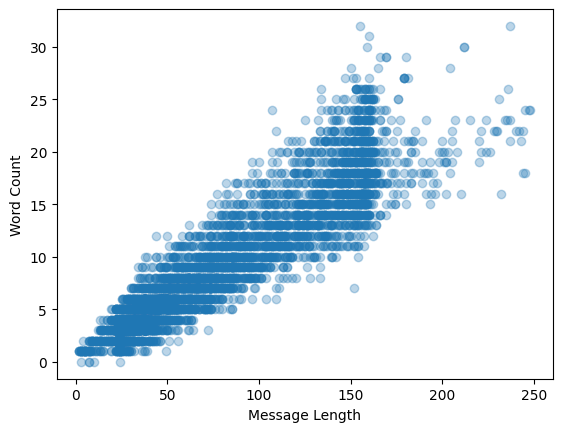

In [30]:
plt.scatter(
    df['length'],
    df['word_count'],
    alpha=0.3
)

plt.xlabel('Message Length')
plt.ylabel('Word Count')
plt.show()

Text(0.5, 0, 'Label')

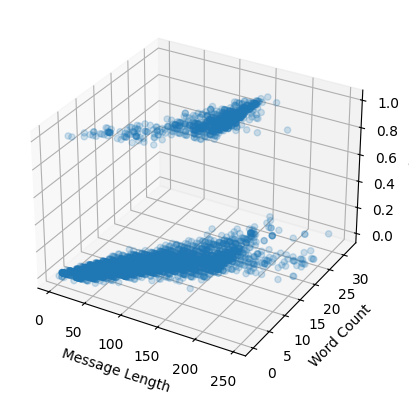

In [31]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['length'],
    df['word_count'],
    df['label'],
    alpha=0.2
)

ax.set_xlabel('Message Length')
ax.set_ylabel('Word Count')
ax.set_zlabel('Label')

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_message'])
y = df['label']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import classification_report

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       950
           1       1.00      0.76      0.86       151

    accuracy                           0.97      1101
   macro avg       0.98      0.88      0.92      1101
weighted avg       0.97      0.97      0.97      1101



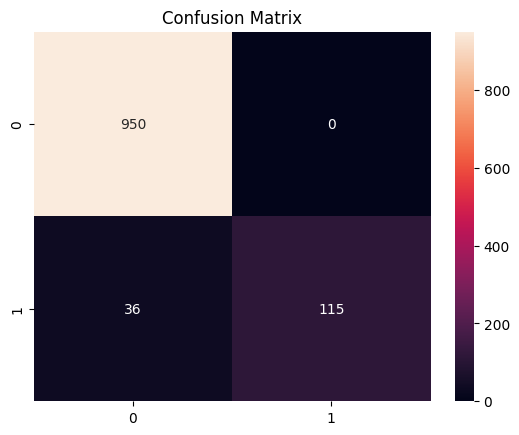

In [42]:
from sklearn.metrics import confusion_matrix
sns.heatmap(
    confusion_matrix(y_test,y_pred),
    annot = True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

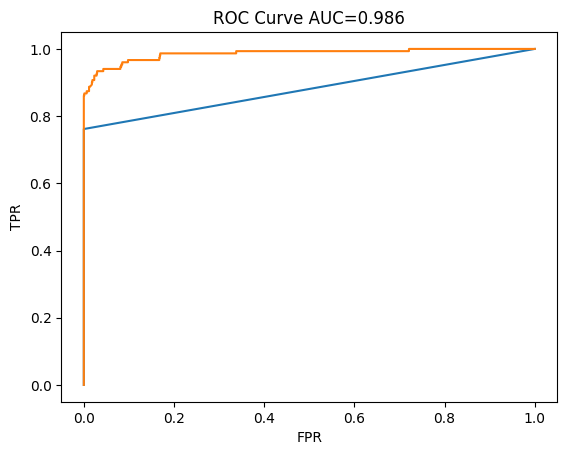

In [43]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test,y_pred)

auc = roc_auc_score(y_test,y_prob)

plt.plot(fpr,tpr)

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)

plt.title("ROC Curve AUC="+str(round(auc,3)))

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.show()

In [44]:
from sklearn.naive_bayes import GaussianNB
X_dense = X.toarray()

X_train, X_test, y_train, y_test = train_test_split(X_dense, y, test_size=0.2,random_state=42)

model = GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [46]:
y_pred = model.predict(X_test)

In [47]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       950
           1       0.99      0.81      0.89       151

    accuracy                           0.97      1101
   macro avg       0.98      0.91      0.94      1101
weighted avg       0.97      0.97      0.97      1101



In [45]:
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB()
model.fit(X_train,y_train)

BernoulliNB()